In [636]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Exploración de los datos
Primeramente nos vamos a familiarizar con la forma de los datos para esto se va a :
- Ver que tamaño tienen.
- Revisar que columnas tienen y tipo de datos de estas
- Verificar la consistencia, unicidad y completitud de los datos.

In [583]:
data = pd.read_csv('data/Datos Lab 1.csv').copy()
data.shape

(2576, 27)

In [520]:
data.iloc[:,0:14].head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,0.05,1.559641,0.5753,1.3783
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,0.22,3.870000,0.9168,2.2274
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,0.12,3.640000,0.7299,2.0651
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,0.54,2.454415,0.7023,3.5649
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,1.00,7.810000,1.9521,5.9400


In [521]:
data.iloc[:,-13:].head()

,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,0.25,2.255577,0.8488,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,0.63,6.130000,1.2544,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,0.38,4.880000,0.9330,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,1.38,4.430375,1.1835,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2.13,10.880000,NaN,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


In [522]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

In [523]:
((data.isnull().sum()/data.shape[0])*100).sort_values(ascending=False)

temp_max_manana      3.687888
viento_min           3.532609
estacion_anio        3.416149
mes                  3.416149
anio                 3.338509
humedad_max          3.338509
viento_media         3.338509
viento_max           3.144410
humedad_min          3.105590
viento_norte         3.105590
presion_desv         3.105590
rafaga_desv          3.066770
direccion_viento     3.066770
rafaga_media         3.027950
registros_del_dia    2.989130
presion_media        2.911491
presion_min          2.872671
humedad_media        2.872671
rafaga_max           2.833851
rafaga_min           2.795031
viento_desv          2.795031
fecha                2.795031
sector_viento        2.756211
dia_del_anio         2.639752
presion_max          2.484472
viento_este          2.484472
humedad_desv         2.368012
dtype: float64

In [524]:
dict = pd.read_excel('./data/Diccionario de datos.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


In [525]:
data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


In [526]:
n_duplicados = int(data.duplicated(keep=False).sum())
print(f"Número de registros duplicados: {n_duplicados}")
dup_counts = (data[["fecha","presion_media"]].groupby('fecha').size().reset_index(name='Count').sort_values(by='Count', ascending=False))

dup_counts= dup_counts[dup_counts['Count']>1]

for id_, n in dup_counts[["fecha","Count"]].values:    
    print(f"fecha={id_} → {n} apariciones")

Número de registros duplicados: 8
fecha=2015-12-07 → 2 apariciones
fecha=2010-10-25 → 2 apariciones
fecha=2010-08-14 → 2 apariciones
fecha=2009-12-08 → 2 apariciones
fecha=2009-05-02 → 2 apariciones
fecha=2009-01-22 → 2 apariciones
fecha=2009-03-05 → 2 apariciones
fecha=2012-10-04 → 2 apariciones
fecha=2012-10-06 → 2 apariciones
fecha=2012-11-13 → 2 apariciones
fecha=2012-11-22 → 2 apariciones
fecha=2013-01-02 → 2 apariciones
fecha=2013-02-08 → 2 apariciones
fecha=2013-04-20 → 2 apariciones
fecha=2013-05-29 → 2 apariciones
fecha=2015-01-07 → 2 apariciones
fecha=2015-02-03 → 2 apariciones
fecha=2015-05-11 → 2 apariciones


# Resultados/Analisis
- Hay 2576 Datos, cada uno con 27 columnas
- De las 27 columnas 23 corresponden a variables cuantitativas
- De las 27 columnas 4 corresponden a variables cualitativas
- De las 23 variables cuantitativas 20 son continuas y 3 discretas
- De las 4 variables cualitativas 2 son ordinales y 2 nominales

In [527]:
continuas = ['presion_media', 'presion_min', 'presion_max','presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 
             'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv' , 'rafaga_media',
             'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento' , 'temp_max_manana']
discretas = ['registros_del_dia', 'anio', 'dia_del_anio']
Ordinales = ['mes', 'fecha']
nominales = ['estacion_anio', 'sector_viento']

## Analisis de consistencia, unicidad y completitud
- Se evidencia que ninguna de las columnas esta completa (hace falta determinar si los datos faltantes corresponden a filas en especifico o a otra razón)
- La consistencia es tambien algo muy a tener en cuenta pues por ejemplo en el mes se pude ver como hay datos que tienenn "January" , otros tienen "JANUARY" y otros "Enero", sin embargo este esta lejos de ser el unico problema de consistencia
- En cuantoa unicidad tenemos 8 registros totalmente iguales y en este caso de acuerdo al contexto dado se determinó que la fecha funge como ID de la muestra es decir aquellos que comparten fecha son repetidos tambien

#### Arreglando problemas de consistencia, unicidad y completitud

- Problemas de consistencia
Estos son faciles de identificar en tanto solo ocurren en las vairables cualitativas y podemos identificarlos con value counts para que queden en la categoria correcta

In [528]:
data["estacion_anio"].value_counts()

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
Primavera                10
PRIMAVERA                10
invierno                  9
INVIERNO                  9
Verano                    9
Invierno                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

In [571]:
mapeo_estacion_anio = {
    "VERANO": "verano",
    "SUMMER": "verano",
    "BERANO": "verano",
    "VERNO": "verano",

    "PRIMAVERA": "primavera",
    "PRIMAV": "primavera",
    "SPRING": "primavera",
    "PRIMAVERAA": "primavera",

    "OTOÑO": "otono",
    "OTONO": "otono",
    "AUTUMN": "otono",
    "FALL": "otono",

    "INVIERNO": "invierno",
    "INVERNIO": "invierno",
    "WINTER": "invierno",

    "INVERANO": "Estacion_Desconocida",
    "VERANO_INVIERNO": "Estacion_Desconocida",
    "EAST": "Estacion_Desconocida",
}

data["estacion_anio_corregida"] = (
    data["estacion_anio"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map(mapeo_estacion_anio)
    .fillna(data["estacion_anio"])
)

data["estacion_anio_corregida"]= data["estacion_anio_corregida"].fillna("Estacion_Desconocida")
data["estacion_anio_corregida"].value_counts()

estacion_anio_corregida
primavera               566
invierno                564
otono                   564
verano                  552
Estacion_Desconocida    330
Name: count, dtype: int64

In [530]:
data["sector_viento"].value_counts()

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
South         19
ne            19
NORTHEAST     17
Sur           16
Noreste       12
o              8
SOUTH          8
NORTH          6
no             6
West           5
WEST           5
North          4
East           4
EAST           4
Sureste        3
Oeste          3
Noroeste       3
SOUTHEAST      3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64

- Ahora vamos a empezar a unificar:

In [531]:
mapeo_viento = {
    # Norte
    "N": "N",
    "n": "N",
    "North": "N",
    "NORTH": "N",
    "Norte": "N",

    # Sur
    "S": "S",
    "s": "S",
    "South": "S",
    "SOUTH": "S",
    "Sur": "S",

    # Este
    "E": "E",
    "e": "E",
    "East": "E",
    "EAST": "E",
    "Este": "E",

    # Oeste
    "O": "O",
    "o": "O",
    "Oeste": "O",
    "West": "O",
    "WEST": "O",

    # Noreste
    "NE": "NE",
    "ne": "NE",
    "Noreste": "NE",
    "NORTHEAST": "NE",

    # Noroeste
    "NO": "NO",
    "no": "NO",
    "Noroeste": "NO",
    "NORTHWEST": "NO",

    # Sureste
    "SE": "SE",
    "se": "SE",
    "Sureste": "SE",
    "SOUTHEAST": "SE",

    # Suroeste
    "SO": "SO",
    "so": "SO",
    "Suroeste": "SO",
    "SOUTHWEST": "SO"
}

data["sector_viento_corregida"] = (
    data["sector_viento"]
    .map(mapeo_viento)
    .fillna(data["sector_viento"])
)

data["sector_viento_corregida"].value_counts()

sector_viento_corregida
SO    774
S     582
NE    472
O     329
N     137
E      87
SE     72
NO     52
Name: count, dtype: int64

In [532]:
data["mes"].value_counts()

mes
May           127
August        125
July          123
January       120
March         118
             ... 
april          16
septiembre     16
junio          16
Jan            13
OCTOBER        13
Name: count, Length: 61, dtype: int64

In [533]:
mapeo_mes= {
    "enero": "January",
    "Enero": "January",
    "Jan": "January",
    "jan": "January",
    "january": "January",
    "JANUARY": "January",


    "Feb": "February",
    "feb": "February",
    "february": "February",
    "FEBRUARY": "February",
    "febrero": "February",

    "MARCH": "March",
    "march": "March",
    "Mar": "March",
    "mar": "March",
    "marzo": "March",

    "APRIL": "April",
    "april": "April",
    "Apr": "April",
    "apr": "April",
    "abril": "April",

    "mayo": "May",
    "may": "May",
    "MAY": "May",


    "junio": "June",
    "JUNE": "June",
    "june": "June",
    "Jun": "June",

    "JULY": "July",
    "july": "July",
    "Jul": "July",
    "Julio": "July",
    "julio": "July",

    "august": "August",
    "AUGUST": "August",
    "Aug": "August",
    "aug": "August",
    "agosto": "August",

    "SEPTEMBER": "September",
    "september": "September",
    "Sep": "September",
    "sep": "September",
    "sept"  : "September",
    "Sept" : "September",
    "septiembre": "September",

    "octubre": "October",
    "oct": "October",
    "Oct": "October",
    "OCTOBER": "October",
    "october": "October",


    "noviembre": "November",
    "NOVEMBER": "November",


    "november": "November",
    "Nov": "November",

    
    "diciembre": "December",
    "december": "December",
    "DECEMBER": "December",
    "Dec": "December"
}

data["mes_corregida"] = (
    data["mes"]
    .map(mapeo_mes)
    .fillna(data["mes"])
)
data["mes_corregida"].value_counts()

mes_corregida
September    235
January      231
December     214
March        213
November     211
July         209
August       209
May          198
October      198
February     197
June         192
April        181
Name: count, dtype: int64

- Problemas de unicidad : primero podemos dropear los resultados completamente iguales

In [534]:
data_woDup = data.drop_duplicates(keep='first').copy()
data_woDup.shape

(2572, 30)

- Ahora podemos resolver problemas de completitud para la fecha para que pueda usarse de id correctamente 

In [535]:
completables = data_woDup[
    (
        data_woDup["fecha"].isna()
        | (data_woDup["fecha"].astype(str).str.strip() == "")
    )
    & data_woDup["dia_del_anio"].notna()
    & data_woDup["anio"].notna()
]
completables

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,estacion_anio_corregida,sector_viento_corregida,mes_corregida
85,NaN,973.3820,971.76,975.24,1.0043,77.666900,59.8600,89.0,7.3810,3.630300,...,144.0,2009.0,86.0,primavera,March,SO,8.97,primavera,SO,March
96,NaN,984.4544,982.66,985.84,0.8370,71.945300,34.6400,98.2,22.1588,5.718600,...,144.0,2009.0,97.0,primavera,January,SO,17.42,primavera,SO,January
224,NaN,988.7032,987.59,990.24,0.6328,71.057200,47.7500,95.9,16.3577,1.659500,...,144.0,2009.0,225.0,verano,August,O,22.05,verano,O,August
237,NaN,989.2619,986.16,990.44,1.1311,78.713500,62.2500,91.4,7.4702,1.439400,...,144.0,2009.0,238.0,verano,February,S,27.47,verano,S,February
266,NaN,996.1611,995.20,997.71,0.6025,88.620800,76.8000,97.6,7.1956,1.132900,...,144.0,2009.0,267.0,otono,September,O,15.36,otono,O,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2407,NaN,991.9774,989.70,994.19,1.4006,0.608340,0.3905,80.8,14.2611,1.847600,...,144.0,2015.0,217.0,Inverano,August,NE,34.41,Estacion_Desconocida,NE,August
2434,NaN,983.5712,980.65,989.33,2.4154,70.488800,44.4100,84.7,13.7964,1.543600,...,144.0,2015.0,244.0,otono,september,SO,20.03,otono,SO,September
2464,NaN,1004.4446,1002.62,1006.43,1.2320,0.006877,0.4476,94.2,17.3187,1.892400,...,144.0,2015.0,274.0,Otoño,October,NE,17.35,otono,NE,October
2529,NaN,1002.1970,999.08,1005.34,2.0512,78.005500,57.3400,93.7,10.8056,10.956240,...,144.0,2015.0,339.0,summer,JANUARY,S,9.80,verano,S,January


In [536]:
completables["fecha"] = (
    pd.to_datetime(
        completables["anio"].astype(int).astype(str) + "-01-01"
    )
    + pd.to_timedelta(completables["dia_del_anio"] - 1, unit="D")
).dt.strftime("%Y-%m-%d")
completables

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,estacion_anio_corregida,sector_viento_corregida,mes_corregida
85,2009-03-27,973.3820,971.76,975.24,1.0043,77.666900,59.8600,89.0,7.3810,3.630300,...,144.0,2009.0,86.0,primavera,March,SO,8.97,primavera,SO,March
96,2009-04-07,984.4544,982.66,985.84,0.8370,71.945300,34.6400,98.2,22.1588,5.718600,...,144.0,2009.0,97.0,primavera,January,SO,17.42,primavera,SO,January
224,2009-08-13,988.7032,987.59,990.24,0.6328,71.057200,47.7500,95.9,16.3577,1.659500,...,144.0,2009.0,225.0,verano,August,O,22.05,verano,O,August
237,2009-08-26,989.2619,986.16,990.44,1.1311,78.713500,62.2500,91.4,7.4702,1.439400,...,144.0,2009.0,238.0,verano,February,S,27.47,verano,S,February
266,2009-09-24,996.1611,995.20,997.71,0.6025,88.620800,76.8000,97.6,7.1956,1.132900,...,144.0,2009.0,267.0,otono,September,O,15.36,otono,O,September
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2407,2015-08-05,991.9774,989.70,994.19,1.4006,0.608340,0.3905,80.8,14.2611,1.847600,...,144.0,2015.0,217.0,Inverano,August,NE,34.41,Estacion_Desconocida,NE,August
2434,2015-09-01,983.5712,980.65,989.33,2.4154,70.488800,44.4100,84.7,13.7964,1.543600,...,144.0,2015.0,244.0,otono,september,SO,20.03,otono,SO,September
2464,2015-10-01,1004.4446,1002.62,1006.43,1.2320,0.006877,0.4476,94.2,17.3187,1.892400,...,144.0,2015.0,274.0,Otoño,October,NE,17.35,otono,NE,October
2529,2015-12-05,1002.1970,999.08,1005.34,2.0512,78.005500,57.3400,93.7,10.8056,10.956240,...,144.0,2015.0,339.0,summer,JANUARY,S,9.80,verano,S,January


- Aqui nos damos cuenta de otro error de consistencia donde el dia del anio no siempre coincide con el mes, viendo los datos completos tenemos que verificar cual es mejor modificar

In [537]:

comparacion = data_woDup[
    data_woDup["anio"].notna()
    & data_woDup["mes_corregida"].notna()
    & data_woDup["dia_del_anio"].notna()
].copy()

meses = {
    "January": 1, "February": 2, "March": 3,
    "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9,
    "October": 10, "November": 11, "December": 12,
}

comparacion["mes_num"] = (
    comparacion["mes_corregida"]
    .astype(str)
    .str.strip()
    .map(meses)
)

comparacion = comparacion[
    comparacion["mes_num"].notna()
].copy()

comparacion["anio"] = pd.to_numeric(
    comparacion["anio"], errors="coerce"
)

comparacion["dia_del_anio"] = pd.to_numeric(
    comparacion["dia_del_anio"], errors="coerce"
)

comparacion = comparacion[
    comparacion["anio"].notna()
    & comparacion["dia_del_anio"].notna()
].copy()

fecha_por_mes = pd.to_datetime(
    comparacion["anio"].astype(int).astype(str)
    + "-"
    + comparacion["mes_num"].astype(int).astype(str)
    + "-01",
    errors="coerce"
)

comparacion["dia_correcto_por_mes"] = (
    fecha_por_mes.dt.dayofyear
)

fecha_por_dia = (
    pd.to_datetime(
        comparacion["anio"].astype(int).astype(str) + "-01-01",
        errors="coerce"
    )
    + pd.to_timedelta(
        comparacion["dia_del_anio"] - 1,
        unit="D"
    )
)

comparacion["mes_correcto_por_dia"] = (
    fecha_por_dia.dt.month
)

correcciones_dia = (
    comparacion["dia_del_anio"]
    != comparacion["dia_correcto_por_mes"]
).sum()

correcciones_mes = (
    comparacion["mes_num"]
    != comparacion["mes_correcto_por_dia"]
).sum()

print(f"Corregir dia_del_anio: {correcciones_dia}")
print(f"Corregir mes: {correcciones_mes}")

Corregir dia_del_anio: 2291
Corregir mes: 1087


Aqui podemos ver que incluso con el sesgo posible de que las correcciones de mes incluyen correcciones de formato (JANUARY a January)  las correcciones de mes son mucho menores a las correcciones de dias que enemos que hacer, por lo cual es mucho mejor asumir que son los meses los que estan mal y corregirlos en base al dia o fecha. Vamos a aplicar la correccion de mes y completar las fechas faltantes

In [538]:
data_woDup.loc[completables.index, "fecha"] = completables["fecha"]
meses = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

mask = (
    data_woDup["anio"].notna()
    & data_woDup["dia_del_anio"].notna()
)

fecha = (
    pd.to_datetime(
        data_woDup.loc[mask, "anio"].astype(int).astype(str) + "-01-01"
    )
    + pd.to_timedelta(
        pd.to_numeric(data_woDup.loc[mask, "dia_del_anio"]),
        unit="D"
    )
    - pd.Timedelta(days=1)
)

data_woDup.loc[mask, "mes_corregida"] = fecha.dt.month.map(meses) 


- Ahora para asegurar consistencia podemos corregir el mes y anio en funcion de la fecha establecida

In [539]:
fecha = pd.to_datetime(data_woDup["fecha"], errors="coerce")

meses = {
    1: "January", 2: "February", 3: "March",
    4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September",
    10: "October", 11: "November", 12: "December"
}

mask = fecha.notna()

data_woDup.loc[mask, "anio"] = fecha.loc[mask].dt.year
data_woDup.loc[mask, "mes_corregida"] = fecha.loc[mask].dt.month.map(meses)

- Ahora sí podemos usar fecha como ID y verificar duplicados

In [540]:
# Detalle de los registros
dup_table = (
    data_woDup[data_woDup['fecha'].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=data_woDup.groupby('fecha')['fecha'].transform('size'))
    .sort_values(['repeticiones', 'fecha'], ascending=[False, True])
)
# Mostrar tabla
dup_table.iloc[:,0:14]

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media
63,2009-03-05,959.860700,958.67000,962.54,0.8964,94.294400,86.0000,97.8,2.8296,1.290800,0.040000,3.450000,0.7870,2.2142
2574,2009-03-05,959.860700,958.67000,962.54,0.8964,NaN,86.0000,97.8,2.8296,1.290800,0.040000,3.450000,0.7870,2.2142
121,2009-05-02,998.118900,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.844400,0.030000,5.290000,1.6412,3.0808
2568,2009-05-02,998.855231,995.99000,999.41,0.9205,77.500000,51.0900,99.6,18.9020,1.844400,0.030000,5.290000,1.6412,3.0808
341,2009-12-08,983.849000,979.45000,991.40,3.7836,0.877951,0.8010,96.8,5.9641,4.534920,0.648000,16.236000,87.1400,2.3154
2575,2009-12-08,983.849000,979.45000,991.40,3.7836,1.021309,0.8010,96.8,5.9641,4.534920,0.648000,16.236000,87.1400,2.3154
590,2010-08-14,990.482800,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.708600,0.320000,2.628399,0.8538,2.8174
2566,2010-08-14,991.272748,989.22000,991.29,0.4346,84.386400,65.1200,95.7,9.4681,1.708600,0.320000,2.628399,0.8538,2.8174
662,2010-10-25,9928.772000,986.97000,998.17,3.4396,79.714900,62.7000,94.3,9.2834,5.987160,0.972000,11.520000,83.1900,3.0240
2562,2010-10-25,9928.772000,986.97000,998.17,3.4396,79.714900,NaN,94.3,9.2834,5.987160,0.972000,11.520000,83.1900,3.0240


In [541]:
dup_table.iloc[:,-13:]

,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,estacion_anio_corregida,sector_viento_corregida,mes_corregida,repeticiones
63,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.370000,primavera,N,March,2.0
2574,0.1826,9.3166,144.0,2009.0,64.0,primavera,July,N,5.956009,primavera,N,March,2.0
121,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NaN,20.890000,primavera,NaN,May,2.0
2568,0.4668,23.7431,144.0,2009.0,122.0,primavera,october,NE,20.890000,primavera,NE,May,2.0
341,-0.8314,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,verano,SO,December,2.0
2575,NaN,233.2095,144.0,2009.0,342.0,verano,Enero,SO,7.120000,verano,SO,December,2.0
590,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,verano,NE,August,2.0
2566,0.6511,39.5952,144.0,2010.0,226.0,verano,August,NE,19.500000,verano,NE,August,2.0
662,-1.2591,251.2583,144.0,2010.0,298.0,otono,October,O,7.340000,otono,O,October,2.0
2562,-1.2591,251.2583,144.0,2010.0,298.0,otono,October,O,7.340000,otono,O,October,2.0


Aqui podemos observar como la mayoria de repetidos se juntan de a parejas, en donde la mayoria de datos son iguales, tan solo en algunos se tiene mas informacion que en otros, lo que podemos hacer aqui es juntar cada pareja de modo tal que quedemos con la que tenga mayor informacion. Ademas los 4 datos que no tienen ni fecha ni dia nos hacen el analisis mas complicado ademas de ser pocos por lo cual termina siendo mejor abandonarlos

In [542]:
filas = []
filas_a_borrar = data_woDup[
    data_woDup["fecha"].isna()
].index.tolist()
for fecha, grupo in dup_table.groupby("fecha"):
    if len(grupo) != 2:
        continue

    fila = grupo.iloc[0].combine_first(grupo.iloc[1])
    fila.name = grupo.index[0]
    filas.append(fila)

    # Guardamos el índice de la segunda fila para eliminarla
    if grupo.iloc[0].notna().sum() >= grupo.iloc[1].notna().sum():
        filas_a_borrar.append(grupo.index[1])
    else:
        filas_a_borrar.append(grupo.index[0])

# Crear tabla con los registros fusionados
dup_fusionados = pd.DataFrame(filas)

len(dup_fusionados), len(filas_a_borrar)


(16, 20)

Asi vemos como de las 36 filas duplicadas, podemos eliminar 4 para quedarnos con 32 y combinar los pares para quedarnos con 16 sin eliminar

In [543]:
dup_table = dup_table.drop(index=filas_a_borrar)
dup_table.update(dup_fusionados)
dup_table.shape

(16, 31)

In [544]:
data_woDup.update(dup_fusionados)
data_woDup = data_woDup.drop(index=filas_a_borrar)
data_woDup.shape

(2552, 30)

Ahora solucionamos mayormente los problemas de unicidad y consistencia nominal. Vamos a resolver los problemas de consistencia numerica

In [545]:
data_woDup.iloc[:,0:14].describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media
count,2477.000000,2479.000000,2490.000000,2473.000000,2479.000000,2476.000000,2467.000000,2492.000000,2468.000000,2461.000000,2471.000000,2482.000000,2474.000000
mean,999.919591,986.685045,991.692454,1.749477,52.406533,45.131507,90.189497,10.625024,3.802702,1.415158,7.624030,13.647866,2.987266
std,309.551368,8.902722,7.699539,1.215269,35.948400,30.160829,10.677505,5.487885,3.293683,3.962071,6.769260,76.174454,27.980800
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,0.000000,0.000000,-1386.273300
25%,984.287800,981.377666,987.062500,0.896400,0.868200,19.475000,88.000000,6.083225,1.654475,0.230000,3.370000,0.757000,2.512575
50%,989.436200,987.070000,991.930000,1.444500,68.521200,49.650000,93.300000,10.216900,2.462750,0.440000,5.050000,1.052600,3.234400
75%,994.381800,992.550000,996.740000,2.251100,80.513250,67.627500,96.500000,14.749150,4.837050,0.960000,9.562042,1.567075,4.280325
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,45.108000,3319.030100,11.465200


Aqui saltan a la luz los siguientes valores. 
- humedad_min tiene un max mayor al de humedad_max
- rafaga media_ tiene un min de -1386
- viento_min tambien tiene un max mas grande que viento_max

In [546]:
data_woDup.iloc[:,-20:].describe()

,viento_min,viento_max,viento_desv,rafaga_media,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2461.000000,2471.000000,2482.000000,2474.000000,2480.000000,2481.000000,2473.000000,2474.000000,2489.000000,2473.000000,2475.000000,2552.00000,2485.000000,2457.000000
mean,1.415158,7.624030,13.647866,2.987266,-2.673584,6.949019,-5.471350,-1.131777,-0.411239,172.106219,144.091717,2012.00000,182.597183,13.822938
std,3.962071,6.769260,76.174454,27.980800,200.826492,3.242317,75.410387,25.175864,1.149156,86.184506,4.127230,2.00098,105.287792,9.150356
min,0.000000,0.000000,0.000000,-1386.273300,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.00000,1.000000,-15.230000
25%,0.230000,3.370000,0.757000,2.512575,0.440000,4.800000,1.013300,-1.643275,-1.237000,90.395500,144.000000,2010.00000,92.000000,7.340000
50%,0.440000,5.050000,1.052600,3.234400,0.670000,6.690000,1.469000,-0.561050,-0.357600,199.727500,144.000000,2012.00000,182.000000,14.370000
75%,0.960000,9.562042,1.567075,4.280325,1.120000,8.850000,2.018500,0.246775,0.318600,227.199800,144.000000,2014.00000,274.000000,20.450000
max,45.184956,45.108000,3319.030100,11.465200,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.00000,366.000000,63.050000


Aqui se ve como:
- rafaga_min tiene un minimo de -9999
- rafaga_desv tiene un minimo de -232.26 
- viento norte tiene un minimo de -1250.463300
- registros_del_dia tiene un max mucho mayor a 144 

Entonces para los min mayores que max vamos a imputar con el valor valido mas cercano

In [547]:
data_woDup["humedad_min_corregida"] = data_woDup["humedad_min"].where(
    data_woDup["humedad_min"] <= data_woDup["humedad_max"],
    data_woDup["humedad_max"]
)
data_woDup["viento_min_corregida"] = data_woDup["viento_min"].where(
    data_woDup["viento_min"] <= data_woDup["viento_max"],
    data_woDup["viento_max"]
)

La rafaga es un valor positivo, siendo que se define como el aumento de una corriente de viento, esto no incluye direcccion lo cual nos dice que todos los valores van a ser minimo asi que vamos a imputar de esta manera al valor mas cercano, lo mismo ocurre para una desviacion que nunca va a ser negativa 

In [558]:
data_woDup["rafaga_min_corregida"] = data_woDup["rafaga_min"].where(
   (0 <= data_woDup["rafaga_min"]) | (data_woDup["rafaga_min"].isna()),
    0
)
data_woDup["rafaga_media_corregida"] = data_woDup["rafaga_media"].where(
   (0 <= data_woDup["rafaga_media"]) | (data_woDup["rafaga_media"].isna()),
    0
)
data_woDup["rafaga_desv_corregida"] = data_woDup["rafaga_desv"].where(
   (0 <= data_woDup["rafaga_desv"]) | (data_woDup["rafaga_desv"].isna()),
    0
)
data_woDup["viento_norte_corregida"] = data_woDup["viento_norte"].where(
   (data_woDup["viento_norte"].mean()-data_woDup["viento_norte"].std() <= data_woDup["viento_norte"]) | (data_woDup["viento_norte"].isna()),
    data_woDup["viento_norte"].mean()
)

data_woDup["rafaga_desv_corregida"].describe()

count    2473.000000
mean        2.911276
std        69.773267
min         0.000000
25%         1.013300
50%         1.469000
75%         2.018500
max      3471.027800
Name: rafaga_desv_corregida, dtype: float64

Con esto resolvemos el problema de los minimos. ahora falta resolver para los maximos de:
- viento_desv
- rafaga_desv
- registros_del_dia

Para las primeras 2 son una desviacion estandar, donde valores mayores a 3 tiende a tener menos del 0.1% de probabiliades de pasar, por lo cual podemos usar esto como marca y como 3 no es un valor real vamos a usar imputacion estadistica para poder poner datos reales

In [559]:
data_woDup["rafaga_desv_corregida"] = data_woDup["rafaga_desv_corregida"].where(
   (3 > data_woDup["rafaga_desv_corregida"]) | (data_woDup["rafaga_desv_corregida"].isna()),
    data_woDup["rafaga_desv_corregida"].mean()
)
data_woDup["viento_desv_corregida"] = data_woDup["viento_desv"].where(
   (3 > data_woDup["viento_desv"]) | (data_woDup["viento_desv"].isna()),
    data_woDup["viento_desv"].mean()
)
data_woDup["rafaga_desv_corregida"].describe()

count    2473.000000
mean        1.482295
std         0.779711
min         0.000000
25%         1.013300
50%         1.469000
75%         2.018500
max         2.997900
Name: rafaga_desv_corregida, dtype: float64

Mientras que registros del dia podemos aplicar el mismo pero con la mediana

In [550]:
data_woDup["registros_del_dia_corregida"] = data_woDup["registros_del_dia"].where(
   (   144 >= data_woDup["registros_del_dia"]) | (data_woDup["registros_del_dia"].isna()),
    data_woDup["registros_del_dia"].median()
)
data_woDup["registros_del_dia_corregida"].describe()

count    2475.000000
mean      143.959596
std         1.363569
min        90.000000
25%       144.000000
50%       144.000000
75%       144.000000
max       144.000000
Name: registros_del_dia_corregida, dtype: float64

Con esto ya aseguramos validez en todos los datos

In [551]:
data_woDup.iloc[:,0:14].describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,viento_max,viento_desv,rafaga_media
count,2477.000000,2479.000000,2490.000000,2473.000000,2479.000000,2476.000000,2467.000000,2492.000000,2468.000000,2461.000000,2471.000000,2482.000000,2474.000000
mean,999.919591,986.685045,991.692454,1.749477,52.406533,45.131507,90.189497,10.625024,3.802702,1.415158,7.624030,13.647866,2.987266
std,309.551368,8.902722,7.699539,1.215269,35.948400,30.160829,10.677505,5.487885,3.293683,3.962071,6.769260,76.174454,27.980800
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,0.000000,0.000000,-1386.273300
25%,984.287800,981.377666,987.062500,0.896400,0.868200,19.475000,88.000000,6.083225,1.654475,0.230000,3.370000,0.757000,2.512575
50%,989.436200,987.070000,991.930000,1.444500,68.521200,49.650000,93.300000,10.216900,2.462750,0.440000,5.050000,1.052600,3.234400
75%,994.381800,992.550000,996.740000,2.251100,80.513250,67.627500,96.500000,14.749150,4.837050,0.960000,9.562042,1.567075,4.280325
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,45.108000,3319.030100,11.465200


In [552]:
data_woDup.iloc[:,-20:].describe()

,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana,humedad_min_corregida,viento_min_corregida,rafaga_min_corregida,rafaga_media_corregida,rafaga_desv_corregida,viento_norte_corregida,viento_desv_corregida,registros_del_dia_corregida
count,2489.000000,2473.000000,2475.000000,2552.00000,2485.000000,2457.000000,2467.000000,2471.000000,2480.000000,2474.000000,2552.000000,2474.000000,2482.000000,2475.000000
mean,-0.411239,172.106219,144.091717,2012.00000,182.597183,13.822938,44.875243,0.948802,1.358271,3.547603,1.526531,-0.626793,2.418245,143.959596
std,1.149156,86.184506,4.127230,2.00098,105.287792,9.150356,29.246020,1.846555,2.409644,1.472367,0.806475,1.555931,3.892582,1.363569
min,-3.718500,0.000000,90.000000,2009.00000,1.000000,-15.230000,0.237700,0.000000,0.000000,0.000000,0.000000,-6.797700,0.000000,90.000000
25%,-1.237000,90.395500,144.000000,2010.00000,92.000000,7.340000,27.540000,0.220000,0.440000,2.512575,1.026600,-1.637825,0.757000,144.000000
50%,-0.357600,199.727500,144.000000,2012.00000,182.000000,14.370000,49.250000,0.420000,0.670000,3.234400,1.497250,-0.561050,1.052600,144.000000
75%,0.318600,227.199800,144.000000,2014.00000,274.000000,20.450000,67.085000,0.905000,1.120000,4.280325,2.095900,0.246775,1.567075,144.000000
max,4.713900,359.796700,287.000000,2015.00000,366.000000,63.050000,100.000000,24.804000,19.895916,11.465200,2.997900,4.809900,13.647866,144.000000


Ahora podemos evaluar la completitud nuevamente

In [560]:
((data_woDup.isnull().sum()/data_woDup.shape[0])*100).sort_values(ascending=True)

fecha                          0.000000
anio                           0.000000
mes_corregida                  0.000000
humedad_desv                   2.351097
presion_max                    2.429467
viento_este                    2.468652
dia_del_anio                   2.625392
sector_viento                  2.703762
sector_viento_corregida        2.703762
viento_desv                    2.742947
viento_desv_corregida          2.742947
rafaga_max                     2.782132
rafaga_min_corregida           2.821317
rafaga_min                     2.821317
presion_min                    2.860502
humedad_media                  2.860502
presion_media                  2.938871
humedad_min                    2.978056
registros_del_dia              3.017241
registros_del_dia_corregida    3.017241
rafaga_media_corregida         3.056426
rafaga_media                   3.056426
viento_norte                   3.056426
viento_norte_corregida         3.056426
presion_desv                   3.095611


Podemos rellenar con media en la mayoria que faltan porque es tan solo el 5%, es decir su impacto no será tan grande

In [577]:
variables_numericas = [
    "presion_media",
    "presion_min",
    "presion_max",
    "presion_desv",
    "humedad_media",
    "humedad_min",
    "humedad_max",
    "humedad_desv",
    "viento_media",
    "viento_min",
    "viento_max",
    "viento_desv",
    "rafaga_media",
    "rafaga_min",
    "rafaga_max",
    "rafaga_desv",
    "viento_norte",
    "viento_este",
    "direccion_viento",
    "registros_del_dia",
    "anio",
    "dia_del_anio",
    "temp_max_manana"
]

# Crear las versiones corregidas
for col in variables_numericas:
    data_woDup[f"{col}_corregida"] = data_woDup[col].fillna(
        data_woDup[col].median()
    )
((data_woDup.isnull().sum()/data_woDup.shape[0])*100).sort_values(ascending=False)

temp_max_manana                3.722571
viento_min                     3.565831
mes                            3.448276
estacion_anio                  3.409091
estacion_anio_corregida        3.409091
humedad_max                    3.330721
viento_media                   3.291536
viento_max                     3.173981
presion_desv                   3.095611
direccion_viento               3.095611
rafaga_desv                    3.095611
rafaga_media                   3.056426
viento_norte                   3.056426
registros_del_dia              3.017241
humedad_min                    2.978056
presion_media                  2.938871
presion_min                    2.860502
humedad_media                  2.860502
rafaga_min                     2.821317
rafaga_max                     2.782132
viento_desv                    2.742947
sector_viento                  2.703762
sector_viento_corregida        2.703762
dia_del_anio                   2.625392
viento_este                    2.468652


Con esto aseguramos la validez de los datos y podemos hacer un mapa de calor para determinar la correlacion de los datos

In [578]:
# Crear una copia del DataFrame original + corregido
data_corregida = data_woDup.copy()

# Identificar columnas corregidas
columnas_corregidas = [
    col for col in data_corregida.columns
    if col.endswith("_corregida")
]

# Quedarnos solo con las columnas corregidas
data_corregida = data_corregida[columnas_corregidas]

# Quitar "_corregida" de los nombres
data_corregida = data_corregida.rename(
    columns={
        col: col.replace("_corregida", "")
        for col in columnas_corregidas
    }
)

estacion_anio        3.409091
sector_viento        2.703762
mes                  0.000000
humedad_min          0.000000
viento_min           0.000000
rafaga_min           0.000000
rafaga_media         0.000000
rafaga_desv          0.000000
viento_norte         0.000000
viento_desv          0.000000
registros_del_dia    0.000000
presion_media        0.000000
presion_min          0.000000
presion_max          0.000000
presion_desv         0.000000
humedad_media        0.000000
humedad_max          0.000000
humedad_desv         0.000000
viento_media         0.000000
viento_max           0.000000
rafaga_max           0.000000
viento_este          0.000000
direccion_viento     0.000000
anio                 0.000000
dia_del_anio         0.000000
temp_max_manana      0.000000
dtype: float64

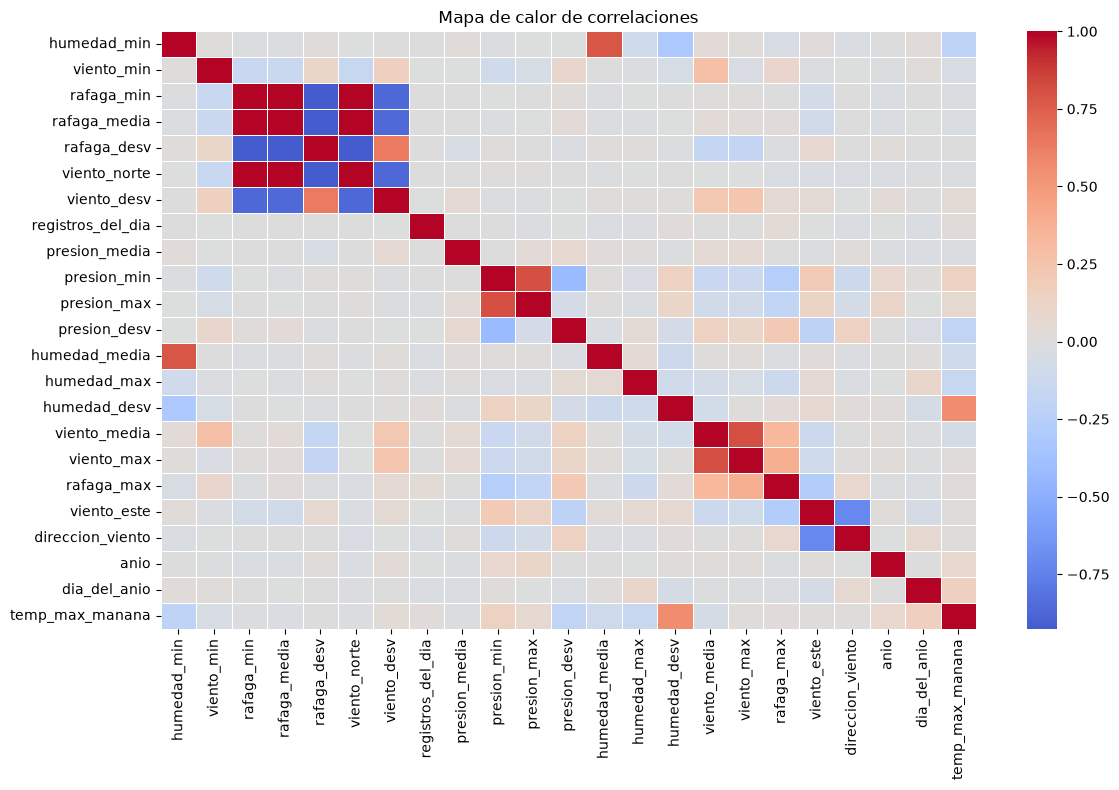

In [602]:
# Matriz de correlación
corr = data_corregida.corr(numeric_only=True)

# Mapa de calor
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=False,       # Mostrar valores
    fmt=".2f",        # 2 decimales
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Mapa de calor de correlaciones")
plt.tight_layout()

((data_corregida.isnull().sum()/data_corregida.shape[0])*100).sort_values(ascending=False)

Podemos ver que realmente solo nos interesan las variables de:
- Humedad
- Presion
- Dia

# Generar los modelos
Primeramente podemos generar un modelo ingenuo que solo toma los valores numericos establecidos y crea un modelo apartir de ellos

In [628]:
Variables= [ 
    'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 
    'presion_media', 'presion_min', 'presion_max','presion_desv',
    'dia_del_anio'
            ]
target = 'temp_max_manana'
data_train = data.copy()
data_train["temp_max_manana"] = data_train["temp_max_manana"].fillna(
    data_train["temp_max_manana"].mean()
)
X = data_train.drop(columns=[target]).copy()
y = data_train[target]

Para asegurar la replicabilidad tenemos que usar una pipeline y empezar con los datos originales

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42)


def drop_columns(df):
    return df.drop(columns=data.columns.difference(Variables), errors="ignore")

dropper = FunctionTransformer(drop_columns)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

En este caso como tomamos el modelo mas simple posible tan solo tenemos las variables numericas. Sin embargo debemos traer las normalizaciones que hicimos antes para humedad min y media. donde nos dimos cuenta que puede que halla casos en donde los valores estan intercambiado pues min es el mayor y min el menor

In [630]:
def normalizar_humedad(df):
    df = df.copy()
    
    mask = df["humedad_min"] > df["humedad_max"]
        
    df.loc[mask, ["humedad_min", "humedad_max"]] = df.loc[mask, ["humedad_max", "humedad_min"]].values

    return df
normalizar_humedad_tr = FunctionTransformer(normalizar_humedad)

Otra cosa que podemos hacer es rellenar el dia en funcion de la fecha

In [631]:
def conseguir_dia(df):
    df = df.copy()
    df["dia_del_anio"] = df["dia_del_anio"].fillna(pd.to_datetime(df["fecha"], errors="coerce").dt.dayofyear)
    return df
connseguir_dia_tr = FunctionTransformer(conseguir_dia)

In [632]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, Variables)
    ]
)
pipeline_regresion = Pipeline(steps=[
    ("Conseguir dias", connseguir_dia_tr),
    ("normalizar_humedad", normalizar_humedad_tr),
    ("dropper", dropper),
    ("preprocesamiento", preprocessor),
])
Xt_train = pipeline_regresion.fit_transform(X_train)
Modelo = LinearRegression()
Modelo.fit(Xt_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.25, 0.33,-1.27,..., 0.2 ,-1.38, 1.93]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,13.77
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[65.34,62.37,48.76,...,39.3 ,17.8 ,14.55]"


In [638]:
y_train_pred = Modelo.predict(Xt_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
print("RMSE train:", rmse_train)
print("MAE  train:", mae_train)
r2_train = r2_score(y_train, y_train_pred)
print("R²   train:", r2_train)

RMSE train: 7.180537165853747
MAE  train: 5.52478764147847
R²   train: 0.38685212676901637


# Tabla comparativa
| Métrica | Modelo 1 | Modelo 2 |
|---|---:|---:|
| MAE Entrenamiento| 5.5248 | 0 |
| RMSE Entrenamiento| 7.180537165853747 | 0 |
| R2 Entrenamiento| 0.38685212676901637 | 0 |
